In [0]:
# Requirements
!pip install 'scipy>=1.8'
!pip install 'networkx<2.7'

You should consider upgrading via the '/local_disk0/.ephemeral_nfs/envs/pythonEnv-af0264f8-4e02-4289-bafa-4981a472f439/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/local_disk0/.ephemeral_nfs/envs/pythonEnv-af0264f8-4e02-4289-bafa-4981a472f439/bin/python -m pip install --upgrade pip' command.


In [0]:
from graphframes import *
from pyspark.sql.types import *
from pyspark.sql import Row
from pyspark.sql.functions import col
import numpy as np

/databricks/python_shell/dbruntime/PythonPackageImportsInstrumentation/__init__.py:171: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.5)
  original_result = python_builtin_import(name, globals, locals, fromlist, level)


###Star Wars Dataset

In [0]:
vertices = spark.createDataFrame([
    ("1", "R2-D2", "Droid", "Rebel Alliance", None),
    ("2", "CHEWBACCA", "Wookiee", "Rebel Alliance", None),
    ("3", "C-3PO", "Droid", "Rebel Alliance", None),
    ("4", "LUKE", "Jedi Knight", "Rebel Alliance", "Skywalker"),
    ("5", "DARTH VADER", "Sith Lord", "Galactic Empire", "Skywalker"),
    ("6", "CAMIE", "Rebel", "Rebel Alliance", "Marstrap"),
    ("7", "BIGGS", "Rebel Pilot", "Rebel Alliance", "Darklighter"),
    ("8", "LEIA", "Princess, Rebel Leader", "Rebel Alliance", "Organa"),
    ("9", "BERU", "Relative", "Rebel Alliance", "Lars"),
    ("10", "OWEN", "Relative", "Rebel Alliance", "Lars"),
    ("11", "OBI-WAN", "Jedi Master", "Rebel Alliance", "Kenobi"),
    ("12", "MOTTI", "Imperial Officer", "Galactic Empire", "Motti"),
    ("13","TARKIN", "Imperial Officer", "Galactic Empire", "Tarkin"),
    ("14", "HAN", "Smuggler turned Rebel", "Rebel Alliance", "Solo"),
    ("15", "DODONNA", "Rebel Leader", "Rebel Alliance", "Dodonna"),
    ("16", "GOLD LEADER", "Rebel Pilot", "Rebel Alliance", "Dreis"),
    ("17", "WEDGE", "Rebel Pilot", "Rebel Alliance", "Antilles"),
    ("18", "RED LEADER", "Rebel Pilot", "Rebel Alliance", "Dodonna"),
    ("19", "RED TEN", "Rebel Pilot", "Rebel Alliance", "Ralter")
], ["id", "character", "role", "side", "family_name"])


edges = spark.createDataFrame([
    ("2", "1", "Allies"),
    ("1", "2", "Allies"),
    ("3", "1", "Allies"),
    ("1", "3", "Allies"),
    ("9", "1", "Allies"),
    ("1", "9", "Allies"),
    ("4", "1", "Allies"),
    ("1", "4", "Allies"),
    ("10", "1", "Allies"),
    ("1", "10", "Allies"),
    ("11", "1", "Allies"),
    ("1", "11", "Allies"),
    ("8", "1", "Allies"),
    ("1", "8", "Allies"),
    ("8", "16", "Allies"),
    ("16", "8", "Allies"),
    ("8", "17", "Allies"),
    ("17", "8", "Allies"),
    ("8", "19", "Allies"),
    ("19", "8", "Allies"),
    ("8", "15", "Allies"),
    ("15", "8", "Allies"),
    ("7", "1", "Allies"),
    ("1", "7", "Allies"),
    ("14", "1", "Allies"),
    ("1", "14", "Allies"),
    ("2", "11", "Allies"),
    ("11", "2", "Allies"),
    ("3", "2", "Allies"),
    ("2", "3", "Allies"),
    ("2", "4", "Allies"),
    ("4", "2", "Allies"),
    ("2", "14", "Allies"),
    ("14", "2", "Allies"),
    ("2", "8", "Allies"),
    ("8", "2", "Allies"),
    ("4", "5", "Family"),
    ("5", "4", "Family"),
    ("6", "4", "Allies"),
    ("4", "6", "Allies"),
    ("7", "6", "Allies"),
    ("6", "7", "Allies"),
    ("7", "4", "Allies"),
    ("4", "7", "Allies"),
    ("5", "8", "Family"),
    ("8", "5", "Family"),
    ("9", "4", "Family"),
    ("4", "9", "Family"),
    ("9", "10", "Family"),
    ("10", "9", "Family"),
    ("9", "3", "Allies"),
    ("3", "9", "Allies"),
    ("4", "10", "Family"),
    ("10", "4", "Family"),
    ("3", "4", "Allies"),
    ("4", "3", "Allies"),
    ("3", "10", "Allies"),
    ("10", "3", "Allies"),
    ("3", "8", "Allies"),
    ("8", "3", "Allies"),
    ("17", "1", "Allies"),
    ("1", "17", "Allies"),
    ("18", "1", "Allies"),
    ("1", "18", "Allies"),
    ("19", "1", "Allies"),
    ("1", "19", "Allies"),
    ("8", "4", "Family"),
    ("4", "8", "Family"),
    ("9", "8", "Allies"),
    ("8", "9", "Allies"),
    ("4", "11", "Allies"),
    ("11", "4", "Allies"),
    ("3", "11", "Allies"),
    ("11", "3", "Allies"),
    ("8", "11", "Allies"),
    ("11", "8", "Allies"),
    ("12", "13", "Allies"),
    ("13", "12", "Allies"),
    ("5", "12", "Allies"),
    ("12", "5", "Allies"),
    ("5", "13", "Allies"),
    ("13", "5", "Allies"),
    ("14", "11", "Allies"),
    ("11", "14", "Allies"),
    ("14", "4", "Allies"),
    ("4", "14", "Allies"),
    ("3", "14", "Allies"),
    ("14", "3", "Allies"),
    ("8", "12", "Enemies"),
    ("12", "8", "Enemies"),
    ("8", "13", "Enemies"),
    ("13", "8", "Enemies"),
    ("14", "8", "Allies"),
    ("8", "14", "Allies"),
    ("5", "11", "Enemies"),
    ("11", "5", "Enemies"),
    ("15", "16", "Allies"),
    ("16", "15", "Allies"),
    ("15", "17", "Allies"),
    ("17", "15", "Allies"),
    ("15", "4", "Allies"),
    ("4", "15", "Allies"),
    ("16", "17", "Allies"),
    ("17", "16", "Allies"),
    ("16", "4", "Allies"),
    ("4", "16", "Allies"),
    ("4", "17", "Allies"),
    ("17", "4", "Allies"),
    ("7", "8", "Allies"),
    ("8", "7", "Allies"),
    ("8", "18", "Allies"),
    ("18", "8", "Allies"),
    ("4", "18", "Allies"),
    ("18", "4", "Allies"),
    ("7", "3", "Allies"),
    ("3", "7", "Allies"),
    ("16", "3", "Allies"),
    ("3", "16", "Allies"),
    ("17", "3", "Allies"),
    ("3", "17", "Allies"),
    ("19", "3", "Allies"),
    ("3", "19", "Allies"),
    ("18", "3", "Allies"),
    ("3", "18", "Allies"),
    ("15", "18", "Family"),
    ("18", "15", "Family"),
    ("7", "18", "Allies"),
    ("18", "7", "Allies"),
    ("7", "19", "Allies"),
    ("19", "7", "Allies"),
    ("16", "19", "Allies"),
    ("19", "16", "Allies"),
    ("17", "19", "Allies"),
    ("19", "17", "Allies"),
    ("18", "17", "Allies"),
    ("17", "18", "Allies"),
    ("16", "18", "Allies"),
    ("18", "16", "Allies"),
    ("7", "17", "Allies"),
    ("17", "7", "Allies"),
    ("18", "19", "Allies"),
    ("19", "18", "Allies"),
    ("7", "16", "Allies"),
    ("16", "7", "Allies"),
    ("15", "19", "Allies"),
    ("19", "15", "Allies"),
    ("16", "1", "Allies"),
    ("1", "16", "Allies"),
    ("4", "19", "Allies"),
    ("19", "4", "Allies"),],
    ["src", "dst", "relationship"])



In [0]:
g_starwars = GraphFrame(vertices, edges)

g_starwars.vertices.show()
g_starwars.edges.show()
g_starwars.degrees.show()

+---+-----------+--------------------+---------------+-----------+
| id|  character|                role|           side|family_name|
+---+-----------+--------------------+---------------+-----------+
|  1|      R2-D2|               Droid| Rebel Alliance|       null|
|  2|  CHEWBACCA|             Wookiee| Rebel Alliance|       null|
|  3|      C-3PO|               Droid| Rebel Alliance|       null|
|  4|       LUKE|         Jedi Knight| Rebel Alliance|  Skywalker|
|  5|DARTH VADER|           Sith Lord|Galactic Empire|  Skywalker|
|  6|      CAMIE|               Rebel| Rebel Alliance|   Marstrap|
|  7|      BIGGS|         Rebel Pilot| Rebel Alliance|Darklighter|
|  8|       LEIA|Princess, Rebel L...| Rebel Alliance|     Organa|
|  9|       BERU|            Relative| Rebel Alliance|       Lars|
| 10|       OWEN|            Relative| Rebel Alliance|       Lars|
| 11|    OBI-WAN|         Jedi Master| Rebel Alliance|     Kenobi|
| 12|      MOTTI|    Imperial Officer|Galactic Empire|      Mo

In [0]:
character_list = vertices.select("id").rdd.flatMap(lambda x: x).collect()

verticesListRDD = sc.parallelize(character_list, 1)
verticesListRowsRDD = verticesListRDD.map( lambda data : Row(data))
verticesSchema = StructType([StructField('id', StringType(), True)])
verticesDataFrame = verticesListRowsRDD.toDF(verticesSchema).persist()
verticesDataFrame.show()

+---+
| id|
+---+
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
| 10|
| 11|
| 12|
| 13|
| 14|
| 15|
| 16|
| 17|
| 18|
| 19|
+---+



In [0]:
edges_list = edges.select('src', 'dst').rdd.map(tuple).collect()

sourceColumn = StructField('src', StringType(),True)
destinationColumn = StructField('dst', StringType(), True)
edgeSchema = StructType([sourceColumn, destinationColumn])
edgeRDD = sc.parallelize(edges_list, 1)
edgeRDDRows = edgeRDD.map( lambda data : Row(data[0], data[1]))
edgeDataFrame = edgeRDDRows.toDF(edgeSchema).persist()
edgeDataFrame.show()

+---+---+
|src|dst|
+---+---+
|  2|  1|
|  1|  2|
|  3|  1|
|  1|  3|
|  9|  1|
|  1|  9|
|  4|  1|
|  1|  4|
| 10|  1|
|  1| 10|
| 11|  1|
|  1| 11|
|  8|  1|
|  1|  8|
|  8| 16|
| 16|  8|
|  8| 17|
| 17|  8|
|  8| 19|
| 19|  8|
+---+---+
only showing top 20 rows



In [0]:
Graphfram = GraphFrame(verticesDataFrame, edgeDataFrame)

In [0]:
# View the inDegrees (the number of edges directed into a vertex)
print(
    Graphfram.inDegrees.show()
)

+---+--------+
| id|inDegree|
+---+--------+
|  7|       9|
| 15|       6|
| 11|       7|
|  3|      13|
|  8|      16|
| 16|       9|
|  5|       5|
| 18|       9|
| 17|       9|
|  6|       2|
| 19|       9|
|  9|       5|
|  1|      13|
| 10|       4|
|  4|      16|
| 12|       3|
| 13|       3|
| 14|       6|
|  2|       6|
+---+--------+

None


In [0]:
# View the inDegrees (the number of edges directed into a vertex)
print(
    Graphfram.outDegrees.show()
)

+---+---------+
| id|outDegree|
+---+---------+
|  7|        9|
| 15|        6|
| 11|        7|
|  3|       13|
|  8|       16|
| 16|        9|
|  5|        5|
| 18|        9|
| 17|        9|
|  6|        2|
| 19|        9|
|  9|        5|
|  1|       13|
| 10|        4|
|  4|       16|
| 12|        3|
| 13|        3|
| 14|        6|
|  2|        6|
+---+---------+

None


###Motifs

#####Rebel Unit Hierarchy

In [0]:
# Define the hierarchy Rebel Leaders -> Pilots -> Droids
g_starwars \
    .find("(a)-[]->(b); (b)-[]->(c)") \
    .filter("a.role LIKE '%Rebel Leader%' AND b.role LIKE '%Rebel Pilot%' AND c.role LIKE 'Droid'") \
    .selectExpr("a.character as Leader", "b.character as Pilot", "c.character as Droid") \
    .show()


+-------+-----------+-----+
| Leader|      Pilot|Droid|
+-------+-----------+-----+
|   LEIA|GOLD LEADER|R2-D2|
|DODONNA|GOLD LEADER|R2-D2|
|   LEIA|    RED TEN|R2-D2|
|DODONNA|    RED TEN|R2-D2|
|   LEIA|      WEDGE|R2-D2|
|DODONNA|      WEDGE|R2-D2|
|   LEIA| RED LEADER|R2-D2|
|DODONNA| RED LEADER|R2-D2|
|   LEIA|      BIGGS|R2-D2|
|   LEIA|    RED TEN|C-3PO|
|DODONNA|    RED TEN|C-3PO|
|   LEIA|      WEDGE|C-3PO|
|DODONNA|      WEDGE|C-3PO|
|   LEIA| RED LEADER|C-3PO|
|DODONNA| RED LEADER|C-3PO|
|   LEIA|GOLD LEADER|C-3PO|
|DODONNA|GOLD LEADER|C-3PO|
|   LEIA|      BIGGS|C-3PO|
+-------+-----------+-----+



#####Characters with the same family name

In [0]:
g_starwars \
    .find("(a)-[e]->(b)") \
    .filter("a.family_name = b.family_name AND a.id < b.id") \
    .select("a.character", "b.character", "a.family_name") \
    .show()


+---------+-----------+-----------+
|character|  character|family_name|
+---------+-----------+-----------+
|     LUKE|DARTH VADER|  Skywalker|
|     OWEN|       BERU|       Lars|
|  DODONNA| RED LEADER|    Dodonna|
+---------+-----------+-----------+



#####Relation between all of the Rebel Pilots

In [0]:
g_starwars \
    .find("(a)-[e]->(b)") \
    .filter("a.role LIKE '%Rebel Pilot%' AND b.role LIKE '%Rebel Pilot%'") \
    .select("a.id", "b.id", "e.relationship", "a.role") \
    .show()


+---+---+------------+-----------+
| id| id|relationship|       role|
+---+---+------------+-----------+
| 19|  7|      Allies|Rebel Pilot|
| 18|  7|      Allies|Rebel Pilot|
| 17|  7|      Allies|Rebel Pilot|
| 16|  7|      Allies|Rebel Pilot|
|  7| 16|      Allies|Rebel Pilot|
| 19| 16|      Allies|Rebel Pilot|
| 18| 16|      Allies|Rebel Pilot|
| 17| 16|      Allies|Rebel Pilot|
|  7| 18|      Allies|Rebel Pilot|
| 19| 18|      Allies|Rebel Pilot|
| 17| 18|      Allies|Rebel Pilot|
| 16| 18|      Allies|Rebel Pilot|
|  7| 17|      Allies|Rebel Pilot|
| 19| 17|      Allies|Rebel Pilot|
| 18| 17|      Allies|Rebel Pilot|
| 16| 17|      Allies|Rebel Pilot|
|  7| 19|      Allies|Rebel Pilot|
| 18| 19|      Allies|Rebel Pilot|
| 17| 19|      Allies|Rebel Pilot|
| 16| 19|      Allies|Rebel Pilot|
+---+---+------------+-----------+



###Paths

####Shortest paths

All of the paths to Darth Vader

In [0]:
g_starwars.shortestPaths(landmarks=["5"]).show()

+---+-----------+--------------------+---------------+-----------+---------+
| id|  character|                role|           side|family_name|distances|
+---+-----------+--------------------+---------------+-----------+---------+
|  7|      BIGGS|         Rebel Pilot| Rebel Alliance|Darklighter| {5 -> 2}|
| 15|    DODONNA|        Rebel Leader| Rebel Alliance|    Dodonna| {5 -> 2}|
| 11|    OBI-WAN|         Jedi Master| Rebel Alliance|     Kenobi| {5 -> 1}|
|  3|      C-3PO|               Droid| Rebel Alliance|       null| {5 -> 2}|
|  8|       LEIA|Princess, Rebel L...| Rebel Alliance|     Organa| {5 -> 1}|
| 16|GOLD LEADER|         Rebel Pilot| Rebel Alliance|      Dreis| {5 -> 2}|
|  5|DARTH VADER|           Sith Lord|Galactic Empire|  Skywalker| {5 -> 0}|
| 18| RED LEADER|         Rebel Pilot| Rebel Alliance|    Dodonna| {5 -> 2}|
| 17|      WEDGE|         Rebel Pilot| Rebel Alliance|   Antilles| {5 -> 2}|
|  6|      CAMIE|               Rebel| Rebel Alliance|   Marstrap| {5 -> 2}|

All the paths to get to Luke and Leia

In [0]:
g_starwars.shortestPaths(landmarks=["4", "8"]).show()

+---+-----------+--------------------+---------------+-----------+----------------+
| id|  character|                role|           side|family_name|       distances|
+---+-----------+--------------------+---------------+-----------+----------------+
|  7|      BIGGS|         Rebel Pilot| Rebel Alliance|Darklighter|{8 -> 1, 4 -> 1}|
| 15|    DODONNA|        Rebel Leader| Rebel Alliance|    Dodonna|{8 -> 1, 4 -> 1}|
| 11|    OBI-WAN|         Jedi Master| Rebel Alliance|     Kenobi|{8 -> 1, 4 -> 1}|
|  3|      C-3PO|               Droid| Rebel Alliance|       null|{8 -> 1, 4 -> 1}|
|  8|       LEIA|Princess, Rebel L...| Rebel Alliance|     Organa|{8 -> 0, 4 -> 1}|
| 16|GOLD LEADER|         Rebel Pilot| Rebel Alliance|      Dreis|{8 -> 1, 4 -> 1}|
|  5|DARTH VADER|           Sith Lord|Galactic Empire|  Skywalker|{8 -> 1, 4 -> 1}|
| 18| RED LEADER|         Rebel Pilot| Rebel Alliance|    Dodonna|{8 -> 1, 4 -> 1}|
| 17|      WEDGE|         Rebel Pilot| Rebel Alliance|   Antilles|{8 -> 1, 4

####Breadth-first search

The paths from Owen Lars to Tarkin without passing through family edges  

In [0]:
g_starwars.bfs(
    fromExpr="id='10'", 
    toExpr="id='13'",
    edgeFilter="relationship != 'Family'"
    ).show()

+--------------------+---------------+--------------------+--------------+--------------------+----------------+--------------------+
|                from|             e0|                  v1|            e1|                  v2|              e2|                  to|
+--------------------+---------------+--------------------+--------------+--------------------+----------------+--------------------+
|{10, OWEN, Relati...|{10, 3, Allies}|{3, C-3PO, Droid,...|{3, 8, Allies}|{8, LEIA, Princes...|{8, 13, Enemies}|{13, TARKIN, Impe...|
|{10, OWEN, Relati...|{10, 1, Allies}|{1, R2-D2, Droid,...|{1, 8, Allies}|{8, LEIA, Princes...|{8, 13, Enemies}|{13, TARKIN, Impe...|
+--------------------+---------------+--------------------+--------------+--------------------+----------------+--------------------+



What about the paths from Chewbacca to Dodonna

In [0]:
g_starwars.bfs(
    fromExpr="id='2'", 
    toExpr="id='15'",
    ).show()

+--------------------+--------------+--------------------+---------------+--------------------+
|                from|            e0|                  v1|             e1|                  to|
+--------------------+--------------+--------------------+---------------+--------------------+
|{2, CHEWBACCA, Wo...|{2, 8, Allies}|{8, LEIA, Princes...|{8, 15, Allies}|{15, DODONNA, Reb...|
|{2, CHEWBACCA, Wo...|{2, 4, Allies}|{4, LUKE, Jedi Kn...|{4, 15, Allies}|{15, DODONNA, Reb...|
+--------------------+--------------+--------------------+---------------+--------------------+



###Vizualization of the network

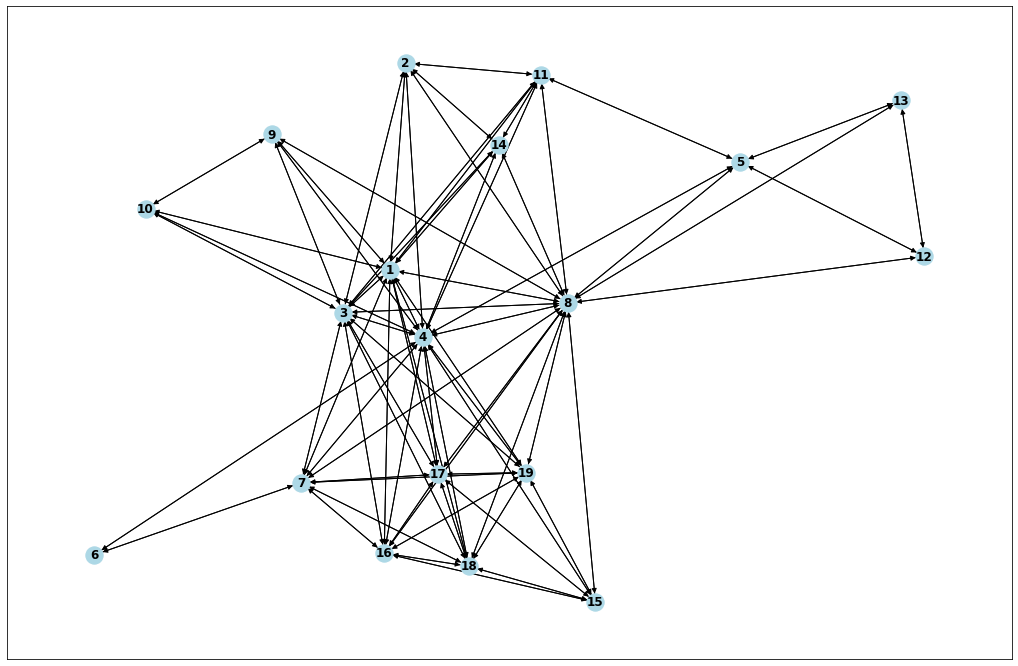

In [0]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a new directed graph
G = nx.DiGraph()

# Add vertices to the graph
for vertex in character_list:
    G.add_node(vertex)

# Add edges to the graph
for edge in edges_list:
    G.add_edge(edge[0], edge[1])

# Draw the graph
plt.figure(figsize=(18, 12))
nx.draw_networkx(G, with_labels=True, node_color='lightblue', font_weight='bold', arrows=True)
plt.show()

**Rebel Alliance Cluster:** Characters like Luke, Leia, Han, and others form a central cluster due to strong alliances.

**Galactic Empire Cluster:** Darth Vader and officers like Tarkin and Motti form a smaller, separate cluster, linked by "Enemies" relationships to Rebels.

Characters like R2-D2 and C-3PO are deeply embedded in the Rebel cluster because of their many "Allies" relationships.

**Central Characters:** Nodes with many edges indicate central or pivotal characters. For instance, Luke, Leia, and R2-D2 are central to the Rebel cluster, while Darth Vader is the focal point of the Empire.

The network highlights inter-faction interactions, such as the alliances within the Rebel Alliance and conflicts with the Galactic Empire.

This graph provides a clear visual representation of character relationships, showing the interconnected nature of the Star Wars universe and emphasizing the dynamics between different factions and characters.

Which character is the most influential one from the plot of Star Wars?

In [0]:
pageRanks = g_starwars.pageRank(resetProbability=0.15, maxIter=5)
pageRanks.vertices.orderBy("pagerank", ascending=False).limit(5).show()

+---+---------+--------------------+--------------+-----------+------------------+
| id|character|                role|          side|family_name|          pagerank|
+---+---------+--------------------+--------------+-----------+------------------+
|  8|     LEIA|Princess, Rebel L...|Rebel Alliance|     Organa|1.9608214350707347|
|  4|     LUKE|         Jedi Knight|Rebel Alliance|  Skywalker|1.9201261061386619|
|  3|    C-3PO|               Droid|Rebel Alliance|       null| 1.528129969467675|
|  1|    R2-D2|               Droid|Rebel Alliance|       null| 1.528129969467675|
|  7|    BIGGS|         Rebel Pilot|Rebel Alliance|Darklighter| 1.108144318110067|
+---+---------+--------------------+--------------+-----------+------------------+



We see that Leia is the most influencial character from the plot